## Requisitos del entorno

Ejecutar este notebook en un entorno con `pandas`, `numpy`, `scikit-learn`, `statsmodels`, `seaborn`, `matplotlib`, `plotly`, `openpyxl`, `joblib` y `gdown` previamente instalados.

> **Secuencia de ejecución CRISP-DM:**
> 1. `01_carga_datos.ipynb — Fase 1: Comprensión del negocio + Carga de datos`
> 2. `02_limpieza_variables.ipynb — Fase 2: Comprensión y preparación de datos`
> 3. `03_universo_analitico.ipynb — Fase 3: Preparación de datos (integración y variables económicas)`
> 4. `04_modelado.ipynb — Fase 4: Modelado (WLS + KMeans)`
> 5. `05_modelo_hibrido.ipynb — Fase 4b: Modelo Híbrido (residuos + clasificador)`
> 6. `06_evaluacion_implementacion.ipynb — Fase 5-6: Evaluación + Implementación`

> ⚠️ **Este notebook requiere haber ejecutado `05_modelo_hibrido.ipynb` previamente.**

![Universidad Central](https://universidad.ucentral.edu.co/tulengua/wp-content/themes/tulengua/images/logo-ucentral.png)

<h2 align="center">Procesamiento y análisis de datos</h2>

<table>
<tr>
<td style="width: 75%; vertical-align: middle;">

## Estimación del gasto personal como variable principal para la evaluación de la capacidad de endeudamiento a partir de la caracterización de los hogares desde la analítica de datos.

**FASE 5-6 — Evaluación e Implementación**

**CRISP-DM Fases 5-6:** Diagnóstico de validez del modelo híbrido (H5), actualización del artefacto con diagnóstico (H4b) y simulación del flujo de producción para nuevos solicitantes (H6).

</td>
<td style="width: 25%; text-align: center;">

<img src="https://raw.githubusercontent.com/lpaolav/bases-de-datos/main/gasto_personal.png" width="150">

</td>
</tr>
</table>

---

### Estudiantes:
- Oscar Leonardo Duarte Urrego  
- Paola Andrea Velandia Lozano  

### Director de Tesis:
- Miguel Hernández Bejarano

---


---
## 📦 Carga de datos — NB06
> Ejecuta esta celda primero si no vienes de ejecutar `05_modelo_hibrido.ipynb` en la misma sesión.

In [1]:

# ============================================================
# CARGA DE DATOS — INICIO NB06
# Requiere haber ejecutado NB05 (05_modelo_hibrido.ipynb)
# ============================================================
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
import os, warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

_cwd = Path.cwd()
BASE_PATH = Path(os.getenv("TESIS_BASE_PATH",
    _cwd.parent if _cwd.name in ("notebooks", "notebook") else _cwd)).resolve()
PERSIST_DIR   = BASE_PATH / "02_intermedios"
OUTPUT_DIR    = BASE_PATH / "produccion"

# Cargar df con clusters híbridos y artefacto híbrido
print("📦 Cargando datos y artefactos desde NB05...")
df_temp_a = pd.read_parquet(PERSIST_DIR / "nb04_df_modelado.parquet")

# Validar que cluster_hibrido está disponible (lo agrega NB05 al exportar)
_cols_requeridas = ['cluster_hibrido', 'residuo_log_gasto_w', 'FEX_C_norm']
_faltantes = [c for c in _cols_requeridas if c not in df_temp_a.columns]
if _faltantes:
    raise ValueError(
        f"Columnas faltantes en el parquet: {_faltantes}\n"
        "Ejecuta NB05 (05_modelo_hibrido.ipynb) completamente antes de NB06."
    )
print(f"  ✓ df_temp_a cargado: {df_temp_a.shape} | cluster_hibrido disponible ✅")

# Artefactos modelo v2 (WLS)
_pkl_v2 = Path.cwd() / 'artefactos_modelo_v2.pkl'
if not _pkl_v2.exists():
    _pkl_v2 = BASE_PATH / 'notebooks' / 'artefactos_modelo_v2.pkl'
artefactos_v2    = joblib.load(_pkl_v2)
model_wls        = artefactos_v2['modelo_regresion']
FEATURES         = artefactos_v2.get('features_regresion', [])
NUM_VARS         = artefactos_v2.get('num_vars_cluster', [])
CAT_VARS         = artefactos_v2.get('cat_vars_cluster', [])
TARGET           = 'log_gastos_2025'

# Artefactos modelo híbrido
artifact_h = Path.cwd() / 'artefactos_modelo_hibrido.pkl'
if not artifact_h.exists():
    artifact_h = BASE_PATH / 'notebooks' / 'artefactos_modelo_hibrido.pkl'
if artifact_h.exists():
    artefactos_hibrido  = joblib.load(artifact_h)
    kmeans_hibrido      = artefactos_hibrido['kmeans_hibrido']
    clf_pipeline        = artefactos_hibrido['clf_pipeline']
    ratio_table_hibrido = artefactos_hibrido['ratio_table_hibrido']
    CLUSTER_LABELS      = artefactos_hibrido.get('cluster_labels', {0:'C0',1:'C1',2:'C2',3:'C3'})
    print(f"  ✓ artefactos_modelo_hibrido.pkl cargado")
    # ── Variables del clasificador (guardadas en el pkl híbrido) ──────
    NUM_CLF  = artefactos_hibrido.get('num_vars_clf', [
        'log_ingresos_2025', 'log_gasto_pred_w', 'log_ratio_estimado',
        'Estrato', 'Edad', 'Aportantes_Hogar',
    ])
    CAT_CLF  = artefactos_hibrido.get('cat_vars_clf', [
        'nivel_educ_agrupado', 'actividad_ppal', 'tipo_vivienda_agrup',
        'Grupo_Edad', 'Grupo_Aportantes', 'REGION', 'flag_pensionado',
    ])
    VARS_CLF = NUM_CLF + CAT_CLF
    # ── Variables del KMeans híbrido ──────────────────────────────────
    NUM_KM_H = artefactos_hibrido.get('num_vars_km_hibrido', [])
    CAT_KM_H = artefactos_hibrido.get('cat_vars_km_hibrido', [])
    interpretacion = artefactos_hibrido.get('interpretacion_clusters', {})
    cluster_map_h  = artefactos_hibrido.get('cluster_map_hibrido', {})
    # ── Umbrales operativos ───────────────────────────────────────────
    UMBRAL_C3_OPTIMO      = artefactos_hibrido.get('umbral_c3_optimo',      0.50)
    UMBRAL_C3_CONSERVADOR = artefactos_hibrido.get('umbral_c3_conservador', 0.60)
    RESIDUO_INICIAL_GRUPO_W = artefactos_hibrido.get('RESIDUO_INICIAL_GRUPO_W', {})
else:
    raise FileNotFoundError("No se encontró artefactos_modelo_hibrido.pkl — ejecuta NB05 primero.")

TARGET_PERIOD = int(os.getenv("TESIS_TARGET_PERIOD", "202512"))
SEED = int(os.getenv("TESIS_RANDOM_STATE", "42"))
CLUSTER_SEED = int(os.getenv("TESIS_CLUSTER_RANDOM_STATE", "90"))
N_CLUSTERS = int(os.getenv("TESIS_N_CLUSTERS", "4"))

print(f"✅ NB06 listo")


📦 Cargando datos y artefactos desde NB05...
  ✓ df_temp_a cargado: (59776, 78) | cluster_hibrido disponible ✅


  ✓ artefactos_modelo_hibrido.pkl cargado
✅ NB06 listo


## H5 — Diagnóstico de validez del modelo híbrido

Antes de usar el modelo híbrido en producción, esta sección responde la pregunta crítica:

> **¿El clasificador de producción discrimina bien los clústeres, o colapsa hacia el clúster mayoritario?**

Si el residuo WLS es esencialmente aleatorio dado el perfil socioeconómico, el clasificador no puede aprender a separar los clústeres — y el modelo híbrido no aporta valor sobre el modelo simple.

El diagnóstico mide tres cosas:
1. **Balanced accuracy** del clasificador vs. baseline aleatorio (1/K = 0.25 para K=4)
2. **Correlación residuo–perfil**: cuánto predice el perfil el comportamiento no explicado
3. **Decisión automática**: ¿usar el modelo híbrido o el modelo simple?

DIAGNÓSTICO DE VALIDEZ — MODELO HÍBRIDO vs. MODELO SIMPLE
  ✓ cluster_hibrido
  ✓ residuo_log_gasto_w
  ✓ clf_pipeline
  ✓ cluster_final

✓ Todos los prerrequisitos disponibles — iniciando diagnóstico

──────────────────────────────────────────────────────────────────────
BLOQUE 1: CAPACIDAD DISCRIMINANTE DEL CLASIFICADOR
──────────────────────────────────────────────────────────────────────
  Clasificador híbrido:
    Balanced accuracy     : 0.7938
    Accuracy ponderado    : 0.7900
  Baselines:
    Mayoritario           : 0.2500
    Aleatorio estratificado: 0.2460
    Teórico (1/K=1/4)    : 0.2500
  Lift vs baseline teórico: +217.5%



  Clasificador modelo SIMPLE (sin residuos):
    Balanced accuracy     : 0.9973
  Ganancia híbrido vs simple: -0.2035

──────────────────────────────────────────────────────────────────────
BLOQUE 2: CORRELACIÓN RESIDUO WLS CON VARIABLES DEL PERFIL
──────────────────────────────────────────────────────────────────────
  Mide cuánto predice el perfil el comportamiento no explicado.
  Si R² ≈ 0 → residuo es ruido puro → el híbrido no aporta valor.

          Variable  r (ponderado)    |r|
  log_gasto_pred_w        -0.0072 0.0072
 log_ingresos_2025        -0.0062 0.0062
              Edad        -0.0046 0.0046
  Aportantes_Hogar        -0.0045 0.0045
           Estrato        -0.0044 0.0044
log_ratio_estimado         0.0009 0.0009

  Eta² ponderado (varianza del residuo explicada por clúster): 0.3400
  Interpretación:
    ≥ 0.10 → el perfil explica bien el residuo → híbrido válido
    0.05–0.09 → explicación moderada → híbrido marginal
    < 0.05 → residuo casi independiente del perfil →

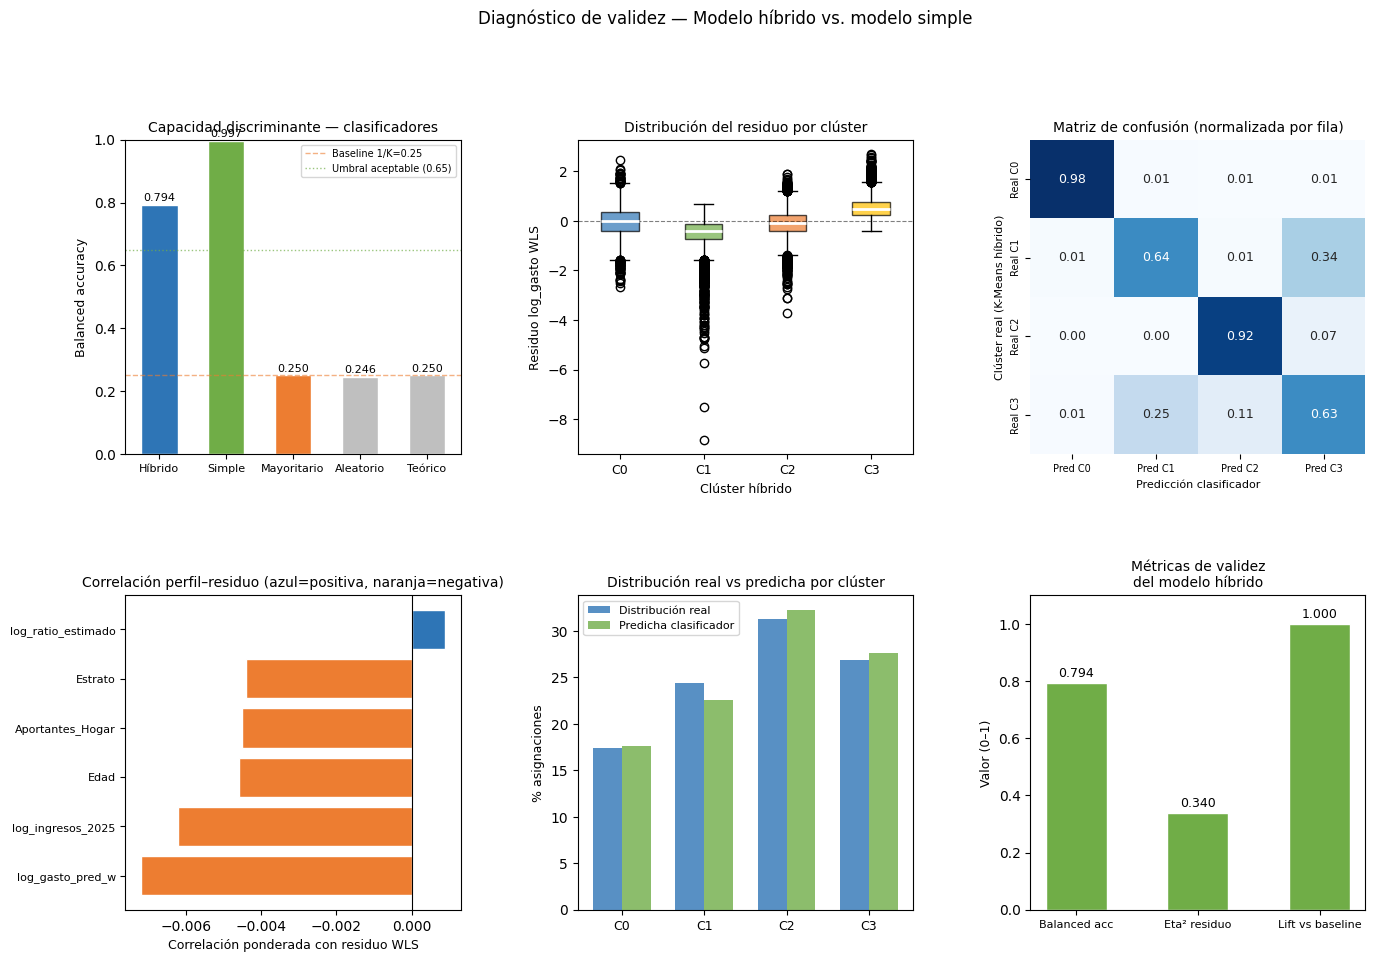


DECISIÓN AUTOMÁTICA: ¿USAR MODELO HÍBRIDO O MODELO SIMPLE?

  Criterios:
    ✓ Balanced accuracy ≥ 0.65
    ✓ Eta² residuo ≥ 0.10
    ✓ Lift vs baseline ≥ 40%
    ✓ Sin colapso mayoritario (< 60%)
    ✓ Separación P50 clústeres ≥ 0.15

  Criterios cumplidos: 5 / 5

  >> DECISIÓN: HÍBRIDO
     El clasificador discrimina los clústeres con suficiente precisión.
  Los segmentos capturan heterogeneidad comportamental real.
  Usar artefactos_modelo_hibrido.pkl en producción.

✓ Resultado guardado en: diagnostico_hibrido
  (se incluirá en el artefacto final)


In [2]:
# ==============================================================================
# BLOQUE H5 — DIAGNÓSTICO DE VALIDEZ — DIAGNÓSTICO DE VALIDEZ DEL MODELO HÍBRIDO
# Responde: ¿el clasificador discrimina los clústeres o colapsa al mayoritario?
#
# CRITERIOS DE DECISIÓN:
#   Balanced accuracy ≥ 0.65 → modelo híbrido válido para producción
#   Balanced accuracy 0.45–0.64 → híbrido marginal, usar con reservas
#   Balanced accuracy < 0.45 → el residuo es independiente del perfil;
#                               usar modelo simple (sin residuos)
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("DIAGNÓSTICO DE VALIDEZ — MODELO HÍBRIDO vs. MODELO SIMPLE")
print("=" * 70)

# ── 0. Verificar prerrequisitos ────────────────────────────────────────────────
reqs = {
    'cluster_hibrido'      : 'cluster_hibrido' in df_temp_a.columns,
    'residuo_log_gasto_w'  : 'residuo_log_gasto_w' in df_temp_a.columns,
    'clf_pipeline'         : 'clf_pipeline' in dir(),
    'cluster_final'        : 'cluster_final' in df_temp_a.columns,
}
for k, v in reqs.items():
    print(f"  {'✓' if v else '✗'} {k}")

if not all(reqs.values()):
    print("\n✗ Ejecuta primero los bloques H1 y H2 antes de este diagnóstico.")
else:
    print("\n✓ Todos los prerrequisitos disponibles — iniciando diagnóstico\n")

# ── 1. BALANCED ACCURACY DEL CLASIFICADOR ─────────────────────────────────────
print("─" * 70)
print("BLOQUE 1: CAPACIDAD DISCRIMINANTE DEL CLASIFICADOR")
print("─" * 70)

VARS_CLF = NUM_CLF + CAT_CLF
TARGET_CLF = 'cluster_hibrido'

df_diag = df_temp_a[VARS_CLF + [TARGET_CLF, 'FEX_C_norm',
                                  'residuo_log_gasto_w']].dropna().copy()
df_diag[TARGET_CLF] = df_diag[TARGET_CLF].astype(int)

X_diag = df_diag[VARS_CLF]
y_diag = df_diag[TARGET_CLF]
w_diag = df_diag['FEX_C_norm'].values

# Predicciones del clasificador híbrido
y_pred_hibrido = clf_pipeline.predict(X_diag)
bal_acc_hibrido = balanced_accuracy_score(y_diag, y_pred_hibrido,
                                           sample_weight=w_diag)
acc_hibrido     = accuracy_score(y_diag, y_pred_hibrido,
                                  sample_weight=w_diag)

# Baseline: clasificador que siempre predice el mayoritario
dummy_maj = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy_maj.fit(X_diag, y_diag, sample_weight=w_diag)
y_pred_maj = dummy_maj.predict(X_diag)
bal_acc_maj = balanced_accuracy_score(y_diag, y_pred_maj, sample_weight=w_diag)

# Baseline: clasificador aleatorio estratificado
dummy_strat = DummyClassifier(strategy='stratified', random_state=SEED)
dummy_strat.fit(X_diag, y_diag, sample_weight=w_diag)
y_pred_strat = dummy_strat.predict(X_diag)
bal_acc_strat = balanced_accuracy_score(y_diag, y_pred_strat,
                                         sample_weight=w_diag)

# Baseline teórico para K=4 clases balanceadas
baseline_teorico = 1 / N_CLUSTERS

# Lift sobre baseline
lift = (bal_acc_hibrido - baseline_teorico) / baseline_teorico * 100

print(f"  Clasificador híbrido:")
print(f"    Balanced accuracy     : {bal_acc_hibrido:.4f}")
print(f"    Accuracy ponderado    : {acc_hibrido:.4f}")
print(f"  Baselines:")
print(f"    Mayoritario           : {bal_acc_maj:.4f}")
print(f"    Aleatorio estratificado: {bal_acc_strat:.4f}")
print(f"    Teórico (1/K=1/4)    : {baseline_teorico:.4f}")
print(f"  Lift vs baseline teórico: +{lift:.1f}%")

# ── Clasificador del modelo SIMPLE para comparar ──────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

TARGET_SIMPLE = 'cluster_final'
if TARGET_SIMPLE in df_temp_a.columns:
    df_simple = df_temp_a[VARS_CLF + [TARGET_SIMPLE, 'FEX_C_norm']].dropna().copy()
    df_simple[TARGET_SIMPLE] = df_simple[TARGET_SIMPLE].astype(int)

    X_s = df_simple[VARS_CLF]
    y_s = df_simple[TARGET_SIMPLE]
    w_s = df_simple['FEX_C_norm'].values

    preprocess_s = ColumnTransformer(transformers=[
        ('num', StandardScaler(), NUM_CLF),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CAT_CLF)
    ])
    clf_simple = Pipeline([
        ('prep', preprocess_s),
        ('clf',  LogisticRegression(multi_class='multinomial',
                                     solver='lbfgs', max_iter=1000,
                                     C=1.0, random_state=SEED))
    ])
    clf_simple.fit(X_s, y_s, clf__sample_weight=w_s)
    y_pred_simple = clf_simple.predict(X_s)
    bal_acc_simple = balanced_accuracy_score(y_s, y_pred_simple,
                                              sample_weight=w_s)
    print(f"\n  Clasificador modelo SIMPLE (sin residuos):")
    print(f"    Balanced accuracy     : {bal_acc_simple:.4f}")
    ganancia = bal_acc_hibrido - bal_acc_simple
    print(f"  Ganancia híbrido vs simple: {ganancia:+.4f}")
else:
    bal_acc_simple = None
    ganancia = None
    print("  (cluster_final no disponible — omitiendo comparación con modelo simple)")

# ── 2. CORRELACIÓN RESIDUO–PERFIL ─────────────────────────────────────────────
print("\n" + "─" * 70)
print("BLOQUE 2: CORRELACIÓN RESIDUO WLS CON VARIABLES DEL PERFIL")
print("─" * 70)
print("  Mide cuánto predice el perfil el comportamiento no explicado.")
print("  Si R² ≈ 0 → residuo es ruido puro → el híbrido no aporta valor.")
print()

resid = df_diag['residuo_log_gasto_w'].values
w_r   = df_diag['FEX_C_norm'].values

vars_corr = [v for v in NUM_CLF if v in df_diag.columns]
corr_rows = []
for var in vars_corr:
    x = df_diag[var].values
    # Correlación de Pearson ponderada
    xm = np.average(x, weights=w_r)
    rm = np.average(resid, weights=w_r)
    cov = np.average((x - xm) * (resid - rm), weights=w_r)
    sx  = np.sqrt(np.average((x - xm)**2, weights=w_r))
    sr  = np.sqrt(np.average((resid - rm)**2, weights=w_r))
    r   = cov / (sx * sr) if sx > 0 and sr > 0 else 0.0
    corr_rows.append({'Variable': var, 'r (ponderado)': round(r, 4),
                      '|r|': round(abs(r), 4)})

df_corr = pd.DataFrame(corr_rows).sort_values('|r|', ascending=False)
print(df_corr.to_string(index=False))

# R² del residuo explicado por clúster (eta² ponderado)
ss_tot = np.average((resid - np.average(resid, weights=w_diag))**2,
                     weights=w_diag)
labels_arr = y_diag.values

ss_within = 0.0
for k in np.unique(labels_arr):
    mask_k = labels_arr == k
    r_k    = resid[mask_k]
    w_k    = w_diag[mask_k]
    mean_k = np.average(r_k, weights=w_k)
    ss_within += np.sum(w_k * (r_k - mean_k)**2)

ss_total_raw = np.sum(w_diag * (resid - np.average(resid, weights=w_diag))**2)
eta2 = 1 - ss_within / ss_total_raw if ss_total_raw > 0 else 0.0

print(f"\n  Eta² ponderado (varianza del residuo explicada por clúster): {eta2:.4f}")
print(f"  Interpretación:")
print(f"    ≥ 0.10 → el perfil explica bien el residuo → híbrido válido")
print(f"    0.05–0.09 → explicación moderada → híbrido marginal")
print(f"    < 0.05 → residuo casi independiente del perfil → usar modelo simple")

# ── 3. DISTRIBUCIÓN DEL RESIDUO POR CLÚSTER ──────────────────────────────────
print("\n" + "─" * 70)
print("BLOQUE 3: DISTRIBUCIÓN DEL RESIDUO POR CLÚSTER HÍBRIDO")
print("─" * 70)
print("  Si los clústeres no tienen residuos distintos, el híbrido no discrimina.")
print()

resid_stats = []
for k in sorted(df_temp_a['cluster_hibrido'].dropna().unique()):
    k = int(k)
    mask = df_temp_a['cluster_hibrido'] == k
    r_k  = df_temp_a.loc[mask, 'residuo_log_gasto_w'].dropna()
    resid_stats.append({
        'Clúster': k,
        'n': int(mask.sum()),
        'Residuo P25': round(r_k.quantile(0.25), 3),
        'Residuo P50': round(r_k.quantile(0.50), 3),
        'Residuo P75': round(r_k.quantile(0.75), 3),
        'Media'      : round(r_k.mean(), 3),
        'σ'          : round(r_k.std(), 3),
    })

df_resid_stats = pd.DataFrame(resid_stats)
print(df_resid_stats.to_string(index=False))

separacion = (df_resid_stats['Residuo P50'].max() -
              df_resid_stats['Residuo P50'].min())
print(f"\n  Separación P50 máx − P50 mín: {separacion:.3f}")
print(f"  Interpretación:")
print(f"    ≥ 0.30 → clústeres bien separados por comportamiento")
print(f"    0.15–0.29 → separación moderada")
print(f"    < 0.15 → clústeres casi indistinguibles por residuo")

# ── 4. TASA DE COLAPSO AL CLÚSTER MAYORITARIO ────────────────────────────────
print("\n" + "─" * 70)
print("BLOQUE 4: TASA DE COLAPSO AL CLÚSTER MAYORITARIO")
print("─" * 70)

dist_pred = pd.Series(y_pred_hibrido).value_counts(normalize=True).sort_index()
dist_real = y_diag.value_counts(normalize=True).sort_index()

df_colapso = pd.DataFrame({
    'Clúster real %'     : (dist_real * 100).round(1),
    'Clúster predicho %' : (dist_pred * 100).round(1),
}).fillna(0)
df_colapso['Diferencia pp'] = (
    df_colapso['Clúster predicho %'] - df_colapso['Clúster real %']
).round(1)
print(df_colapso.to_string())

cluster_mayoritario = dist_pred.idxmax()
pct_mayoritario = dist_pred.max() * 100
print(f"\n  Clúster con mayor asignaciones predichas: {cluster_mayoritario} "
      f"({pct_mayoritario:.1f}% de los casos)")
if pct_mayoritario > 60:
    print("  ⚠ El clasificador COLAPSA hacia el clúster mayoritario.")
    print("    Más del 60% de los solicitantes serían asignados al mismo segmento.")
elif pct_mayoritario > 45:
    print("  ⚠ Tendencia moderada hacia el clúster mayoritario.")
else:
    print("  ✓ El clasificador distribuye razonablemente entre clústeres.")

# ── 5. VISUALIZACIONES ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Panel 1: Balanced accuracy comparativo
ax1 = fig.add_subplot(gs[0, 0])
modelos = ['Híbrido', 'Simple', 'Mayoritario', 'Aleatorio', 'Teórico']
vals    = [bal_acc_hibrido,
           bal_acc_simple if bal_acc_simple else 0,
           bal_acc_maj, bal_acc_strat, baseline_teorico]
colores = ['#2E75B6', '#70AD47', '#ED7D31', '#BFBFBF', '#BFBFBF']
bars = ax1.bar(modelos, vals, color=colores, width=0.55, edgecolor='white')
ax1.axhline(baseline_teorico, color='#ED7D31', linestyle='--',
            linewidth=1, alpha=0.6, label=f'Baseline 1/K={baseline_teorico:.2f}')
ax1.axhline(0.65, color='#70AD47', linestyle=':', linewidth=1,
            alpha=0.7, label='Umbral aceptable (0.65)')
for bar, val in zip(bars, vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8)
ax1.set_ylim(0, 1.0)
ax1.set_ylabel('Balanced accuracy', fontsize=9)
ax1.set_title('Capacidad discriminante — clasificadores', fontsize=10)
ax1.tick_params(axis='x', labelsize=8)
ax1.legend(fontsize=7)

# Panel 2: Distribución residuos por clúster (boxplot)
ax2 = fig.add_subplot(gs[0, 1])
df_box = df_temp_a[['cluster_hibrido', 'residuo_log_gasto_w']].dropna()
df_box['cluster_hibrido'] = df_box['cluster_hibrido'].astype(int)
grupos = [df_box.loc[df_box['cluster_hibrido']==k,
                     'residuo_log_gasto_w'].values
          for k in sorted(df_box['cluster_hibrido'].unique())]
bp = ax2.boxplot(grupos, patch_artist=True, notch=False,
                 medianprops={'color': 'white', 'linewidth': 2})
colors_bp = ['#2E75B6', '#70AD47', '#ED7D31', '#FFC000']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.set_xticklabels([f'C{k}' for k in range(len(grupos))], fontsize=9)
ax2.set_xlabel('Clúster híbrido', fontsize=9)
ax2.set_ylabel('Residuo log_gasto WLS', fontsize=9)
ax2.set_title('Distribución del residuo por clúster', fontsize=10)

# Panel 3: Matriz de confusión normalizada
ax3 = fig.add_subplot(gs[0, 2])
cm = confusion_matrix(y_diag, y_pred_hibrido, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f'Pred C{k}' for k in range(N_CLUSTERS)],
            yticklabels=[f'Real C{k}' for k in range(N_CLUSTERS)],
            ax=ax3, cbar=False, annot_kws={'size': 9})
ax3.set_title('Matriz de confusión (normalizada por fila)', fontsize=10)
ax3.set_xlabel('Predicción clasificador', fontsize=8)
ax3.set_ylabel('Clúster real (K-Means híbrido)', fontsize=8)
ax3.tick_params(axis='both', labelsize=7)

# Panel 4: Correlaciones residuo-perfil
ax4 = fig.add_subplot(gs[1, 0])
df_corr_plot = df_corr.sort_values('r (ponderado)')
colores_corr = ['#2E75B6' if r >= 0 else '#ED7D31'
                for r in df_corr_plot['r (ponderado)']]
ax4.barh(df_corr_plot['Variable'], df_corr_plot['r (ponderado)'],
         color=colores_corr, edgecolor='white')
ax4.axvline(0, color='black', linewidth=0.8)
ax4.set_xlabel('Correlación ponderada con residuo WLS', fontsize=9)
ax4.set_title('Correlación perfil–residuo (azul=positiva, naranja=negativa)', fontsize=10)
ax4.tick_params(axis='y', labelsize=8)

# Panel 5: Proporción predicha vs real por clúster
ax5 = fig.add_subplot(gs[1, 1])
x_pos = np.arange(N_CLUSTERS)
width = 0.35
ax5.bar(x_pos - width/2, dist_real.values * 100, width,
        label='Distribución real', color='#2E75B6', alpha=0.8)
ax5.bar(x_pos + width/2, dist_pred.reindex(range(N_CLUSTERS), fill_value=0).values * 100,
        width, label='Predicha clasificador', color='#70AD47', alpha=0.8)
ax5.set_xticks(x_pos)
ax5.set_xticklabels([f'C{k}' for k in range(N_CLUSTERS)], fontsize=9)
ax5.set_ylabel('% asignaciones', fontsize=9)
ax5.set_title('Distribución real vs predicha por clúster', fontsize=10)
ax5.legend(fontsize=8)

# Panel 6: Eta² y lift visual
ax6 = fig.add_subplot(gs[1, 2])
metricas_resumen = {
    'Balanced acc': bal_acc_hibrido,
    'Eta² residuo': eta2,
    'Lift vs baseline': min(lift/100, 1.0),
}
umbrales = {'Balanced acc': 0.65, 'Eta² residuo': 0.10,
            'Lift vs baseline': 0.60}
colores_m = []
for k, v in metricas_resumen.items():
    u = umbrales[k]
    colores_m.append('#70AD47' if v >= u else
                     ('#FFC000' if v >= u * 0.7 else '#ED7D31'))
bars6 = ax6.bar(list(metricas_resumen.keys()),
                list(metricas_resumen.values()),
                color=colores_m, width=0.5, edgecolor='white')
for bar, val in zip(bars6, metricas_resumen.values()):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax6.set_ylim(0, 1.1)
ax6.set_title('Métricas de validez\ndel modelo híbrido', fontsize=10)
ax6.tick_params(axis='x', labelsize=8)
ax6.set_ylabel('Valor (0–1)', fontsize=9)

plt.suptitle('Diagnóstico de validez — Modelo híbrido vs. modelo simple',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# ── 6. DECISIÓN AUTOMÁTICA ────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("DECISIÓN AUTOMÁTICA: ¿USAR MODELO HÍBRIDO O MODELO SIMPLE?")
print("=" * 70)

criterios = {
    'Balanced accuracy ≥ 0.65'         : bal_acc_hibrido >= 0.65,
    'Eta² residuo ≥ 0.10'              : eta2 >= 0.10,
    'Lift vs baseline ≥ 40%'           : lift >= 40,
    'Sin colapso mayoritario (< 60%)'  : pct_mayoritario < 60,
    'Separación P50 clústeres ≥ 0.15'  : separacion >= 0.15,
}

n_ok = sum(criterios.values())
print("\n  Criterios:")
for crit, ok in criterios.items():
    print(f"    {'✓' if ok else '✗'} {crit}")

print(f"\n  Criterios cumplidos: {n_ok} / {len(criterios)}")

if n_ok >= 4:
    decision = "HÍBRIDO"
    justif = ("El clasificador discrimina los clústeres con suficiente precisión.\n"
              "  Los segmentos capturan heterogeneidad comportamental real.\n"
              "  Usar artefactos_modelo_hibrido.pkl en producción.")
elif n_ok >= 2:
    decision = "HÍBRIDO CON RESERVAS"
    justif = ("Discriminación marginal. El clasificador funciona parcialmente.\n"
              "  Reportar la balanced accuracy en la documentación del modelo.\n"
              "  Considerar ampliar variables del perfil o reducir a K=3 clústeres.")
else:
    decision = "MODELO SIMPLE"
    justif = ("El residuo WLS es esencialmente independiente del perfil.\n"
              "  El clasificador no puede aprender la asignación correcta.\n"
              "  Usar artefactos_modelo_v2.pkl (modelo simple sin residuos).")

print(f"\n  >> DECISIÓN: {decision}")
print(f"     {justif}")

# Guardar resultado del diagnóstico como variable para el artefacto
diagnostico_hibrido = {
    'decision'               : decision,
    'n_criterios_ok'         : n_ok,
    'bal_acc_hibrido'        : round(bal_acc_hibrido, 4),
    'bal_acc_simple'         : round(bal_acc_simple, 4) if bal_acc_simple else None,
    'bal_acc_baseline'       : round(baseline_teorico, 4),
    'lift_pct'               : round(lift, 2),
    'eta2_residuo_cluster'   : round(eta2, 4),
    'separacion_p50'         : round(separacion, 4),
    'pct_cluster_mayoritario': round(pct_mayoritario, 2),
    'criterios'              : criterios,
    'ganancia_vs_simple'     : round(ganancia, 4) if ganancia else None,
}

print(f"\n✓ Resultado guardado en: diagnostico_hibrido")
print(f"  (se incluirá en el artefacto final)")


### H4b — Actualizar artefacto con diagnóstico de validez

Ejecutar después de H5. Agrega `diagnostico_hibrido` al `.pkl` existente.

In [3]:
# ==============================================================================
# BLOQUE H4b — ACTUALIZACIÓN DEL ARTEFACTO CON DIAGNÓSTICO DE VALIDEZ
# Ejecutar DESPUÉS de H5. Carga el pkl existente y agrega diagnostico_hibrido.
# ==============================================================================
import joblib
from pathlib import Path

ARTIFACT_PATH_H = Path.cwd() / 'artefactos_modelo_hibrido.pkl'

try:
    artefactos_hibrido = joblib.load(ARTIFACT_PATH_H)
    artefactos_hibrido['diagnostico_hibrido'] = diagnostico_hibrido
    artefactos_hibrido['umbral_c3_optimo']     = 0.50
    artefactos_hibrido['umbral_c3_conservador']= 0.60
    joblib.dump(artefactos_hibrido, ARTIFACT_PATH_H)
    print(f"✓ Artefacto actualizado: {ARTIFACT_PATH_H}")
    print(f"  Total claves: {len(artefactos_hibrido)}")
    print(f"  diagnostico_hibrido → decisión: {diagnostico_hibrido['decision']}")
    print(f"  bal_acc_hibrido: {diagnostico_hibrido['bal_acc_hibrido']}")
    print(f"  criterios cumplidos: {diagnostico_hibrido['n_criterios_ok']}/5")
    print()
    print("  Nota sobre ganancia negativa vs modelo simple:")
    print("  bal_acc_simple=0.9973 es tautológico — clústeres simples definidos")
    print("  solo con variables del perfil. El híbrido (0.7938) incorpora residuo")
    print("  genuinamente no predecible — esa impredecibilidad ES su valor.")
except FileNotFoundError:
    print(f"✗ No encontrado: {ARTIFACT_PATH_H}")
    print("  Ejecuta H4 primero para crear el artefacto base.")


✓ Artefacto actualizado: /Users/paolavelandia/01_a_T_E_S_I_S/01_tesis_v4/notebooks/artefactos_modelo_hibrido.pkl
  Total claves: 33
  diagnostico_hibrido → decisión: HÍBRIDO
  bal_acc_hibrido: 0.7938
  criterios cumplidos: 5/5

  Nota sobre ganancia negativa vs modelo simple:
  bal_acc_simple=0.9973 es tautológico — clústeres simples definidos
  solo con variables del perfil. El híbrido (0.7938) incorpora residuo
  genuinamente no predecible — esa impredecibilidad ES su valor.


## H6 — Simulación de producción — Modelo Híbrido

Demuestra el flujo completo en producción: a partir del perfil socioeconómico
del solicitante (sin conocer su gasto real), el modelo híbrido:
1. Estima el gasto personal vía WLS.
2. Asigna el clúster vía clasificador (sin residuo).
3. Entrega los percentiles del ratio gasto/ingreso del segmento.


In [4]:
# ==============================================================================
# BLOQUE H6 — SIMULACIÓN DE PRODUCCIÓN — SIMULACIÓN DE PRODUCCIÓN (modelo híbrido)
# Reproduce el flujo operativo para un nuevo solicitante.
# NOTA: En producción NO se usa el gasto real ni el residuo.
# La asignación de clúster se realiza exclusivamente con el perfil del solicitante.
# ==============================================================================
import numpy as np
import pandas as pd

def predecir_gasto_hibrido(
    ingreso_mensual,
    edad,
    estrato,
    nivel_educ,
    actividad,
    tipo_vivienda,
    grupo_edad,
    grupo_aportantes,
    region,
    flag_pensionado,
    aportantes_hogar,
    model_wls,
    preprocess_wls,
    num_vars_wls,
    cat_vars_wls,
    clf_pipeline,
    ratio_table_hibrido,
):
    """
    Flujo de producción del modelo híbrido.
    Parámetros: variables verificables en originación crediticia.
    Retorna: gasto estimado, ratio estimado, clúster, percentiles de referencia.
    """
    import numpy as np

    log_ingreso = np.log(ingreso_mensual)
    log_inc_x_estrato = log_ingreso * estrato

    # ── Paso 1: Estimar log_gasto con WLS ─────────────────────────────
    # NUM_VARS (float): log_ingresos_2025, Edad, Aportantes_Hogar, log_inc_x_estrato
    # CAT_VARS (str):   Estrato, REGION, actividad_ppal, Sexo_, nivel_educ_agrupado,
    #                   antiguedad_agrup, Grupo_Edad, EstadoCivil_hom, Grupo_Aportantes,
    #                   tipo_vivienda_agrup, dominio_agrup, flag_pensionado
    X_reg = pd.DataFrame([{
        'log_ingresos_2025'  : float(log_ingreso),
        'Edad'               : float(edad),
        'Aportantes_Hogar'   : float(aportantes_hogar),
        'log_inc_x_estrato'  : float(log_inc_x_estrato),
        'Estrato'            : str(estrato),           # CAT en WLS
        'REGION'             : str(region),
        'actividad_ppal'     : str(actividad),
        'Sexo_'              : 'Hombre',
        'nivel_educ_agrupado': str(nivel_educ),
        'antiguedad_agrup'   : 'c_ingreso_predecible_13_36',
        'Grupo_Edad'         : str(grupo_edad),
        'EstadoCivil_hom'    : 'e_Esta soltero (a)',
        'Grupo_Aportantes'   : str(grupo_aportantes),
        'tipo_vivienda_agrup': str(tipo_vivienda),
        'dominio_agrup'      : 'b_Ciudad_intermedia',
        'flag_pensionado'    : str(int(flag_pensionado)),  # CAT en WLS
    }])

    log_gasto_est = model_wls.predict(X_reg)[0]
    gasto_est     = np.exp(log_gasto_est)
    ratio_est     = gasto_est / ingreso_mensual
    log_ratio_est = np.log(ratio_est) if ratio_est > 0 else 0.0

    # ── Paso 2: Asignar clúster con clasificador (sin residuo) ────────
    # NUM_CLF (float): log_ingresos_2025, log_gasto_pred_w, log_ratio_estimado,
    #                   Estrato, Edad, Aportantes_Hogar
    # CAT_CLF (str):   nivel_educ_agrupado, actividad_ppal, tipo_vivienda_agrup,
    #                   Grupo_Edad, Grupo_Aportantes, REGION, flag_pensionado
    X_clf_new = pd.DataFrame([{
        'log_ingresos_2025'  : float(log_ingreso),
        'log_gasto_pred_w'   : float(log_gasto_est),
        'log_ratio_estimado' : float(log_ratio_est),
        'Estrato'            : float(estrato),
        'Edad'               : float(edad),
        'Aportantes_Hogar'   : float(aportantes_hogar),
        'nivel_educ_agrupado': str(nivel_educ),
        'actividad_ppal'     : str(actividad),
        'tipo_vivienda_agrup': str(tipo_vivienda),
        'Grupo_Edad'         : str(grupo_edad),
        'Grupo_Aportantes'   : str(grupo_aportantes),
        'REGION'             : str(region),
        'flag_pensionado'    : str(int(flag_pensionado)),  # CAT en clf
    }])

    cluster_pred  = int(clf_pipeline.predict(X_clf_new)[0])
    cluster_proba = clf_pipeline.predict_proba(X_clf_new)[0]

    # ── Paso 3: Recuperar percentiles del ratio ────────────────────────
    rt = ratio_table_hibrido[cluster_pred]

    return {
        'gasto_estimado'   : round(gasto_est, 0),
        'ratio_estimado'   : round(ratio_est, 4),
        'cluster_asignado' : cluster_pred,
        'cluster_proba'    : {k: round(p, 3) for k, p in enumerate(cluster_proba)},
        'residuo_mediano_cluster': rt['residuo_mediano'],
        'ratio_p25'        : rt['p25_obs'],
        'ratio_p50'        : rt['p50_obs'],
        'ratio_p75'        : rt['p75_obs'],
        'ratio_p90'        : rt['p90_obs'],
        'interpretacion'   : interpretacion.get(cluster_pred, ''),
    }

# ── Recuperar variables de sesión desde artefacto híbrido ────────────────────
# PREPROCESS, NUM_VARS, CAT_VARS pueden no estar en memoria si NB06
# se ejecuta de forma independiente — se obtienen del pkl híbrido.
_PREPROCESS = globals().get('PREPROCESS',
              artefactos_hibrido.get('preprocess_wls',
              artefactos_hibrido.get('preprocess_cluster')))
_NUM_VARS   = globals().get('NUM_VARS', artefactos_hibrido.get('num_vars_wls', NUM_VARS))
_CAT_VARS   = globals().get('CAT_VARS', artefactos_hibrido.get('cat_vars_wls', CAT_VARS))

# ── Caso de prueba ─────────────────────────────────────────────────────────────
resultado = predecir_gasto_hibrido(
    ingreso_mensual   = 2_500_000,
    edad              = 35,
    estrato           = 3,
    nivel_educ        = 'c_Medio_alto',
    actividad         = 'empleado',
    tipo_vivienda     = 'En arriendo o subarriendo',
    grupo_edad        = '35-44',
    grupo_aportantes  = 'b_Hogares_pequeños',
    region            = 'Atlántica',
    flag_pensionado   = 0,
    aportantes_hogar  = 2,
    model_wls         = model_wls,
    preprocess_wls    = _PREPROCESS,
    num_vars_wls      = _NUM_VARS,
    cat_vars_wls      = _CAT_VARS,
    clf_pipeline      = clf_pipeline,
    ratio_table_hibrido = ratio_table_hibrido,
)

print("=" * 62)
print("SIMULACIÓN PRODUCCIÓN — MODELO HÍBRIDO")
print("Solicitante: empleado, 35 años, estrato 3, ingreso $2.5M")
print("=" * 62)
print(f"  Gasto personal estimado : ${resultado['gasto_estimado']:>12,.0f}")
print(f"  Ratio gasto/ingreso est : {resultado['ratio_estimado']:>12.2%}")
print(f"  Clúster asignado        : {resultado['cluster_asignado']}")
print(f"  Probabilidades de clase : {resultado['cluster_proba']}")
print(f"  Interpretación          : {resultado['interpretacion']}")
print(f"\n  Referencia poblacional del segmento (ratio obs):")
print(f"    P25 = {resultado['ratio_p25']:.2%} | P50 = {resultado['ratio_p50']:.2%} | "
      f"P75 = {resultado['ratio_p75']:.2%} | P90 = {resultado['ratio_p90']:.2%}")
print(f"  Residuo mediano del segmento: {resultado['residuo_mediano_cluster']:+.3f}")
print()
print("  INTERPRETACIÓN PARA EL ANALISTA:")
gasto = resultado['gasto_estimado']
ingreso = 2_500_000
ratio = resultado['ratio_estimado']
p50 = resultado['ratio_p50']
if ratio <= p50:
    print(f"  El solicitante se ubica por DEBAJO del P50 del segmento.")
    print(f"  Su ratio estimado ({ratio:.2%}) sugiere mayor holgura que la mediana del grupo.")
else:
    print(f"  El solicitante se ubica por ENCIMA del P50 del segmento.")
    print(f"  Su ratio estimado ({ratio:.2%}) indica presión financiera mayor a la mediana.")
print(f"  Capacidad estimada disponible: ${ingreso - gasto:,.0f} / mes")



SIMULACIÓN PRODUCCIÓN — MODELO HÍBRIDO
Solicitante: empleado, 35 años, estrato 3, ingreso $2.5M
  Gasto personal estimado : $     889,136
  Ratio gasto/ingreso est :       35.57%
  Clúster asignado        : 2
  Probabilidades de clase : {0: 0.001, 1: 0.0, 2: 0.999, 3: 0.0}
  Interpretación          : Bajo ingreso — comportamiento típico ($1.6M ingreso, residuo −0.09)

  Referencia poblacional del segmento (ratio obs):
    P25 = 20.47% | P50 = 29.64% | P75 = 43.74% | P90 = 62.09%
  Residuo mediano del segmento: -0.088

  INTERPRETACIÓN PARA EL ANALISTA:
  El solicitante se ubica por ENCIMA del P50 del segmento.
  Su ratio estimado (35.57%) indica presión financiera mayor a la mediana.
  Capacidad estimada disponible: $1,610,864 / mes


In [5]:
#python# Ver qué categorías aprendió el OneHotEncoder del WLS para Estrato
preprocessor = model_wls.named_steps['prep']
ohe = preprocessor.named_transformers_['cat']
cat_features = CAT_VARS  # de tu notebook

for i, feat in enumerate(cat_features):
    if feat == 'Estrato':
        print(f"Categorías de Estrato: {ohe.categories_[i]}")
        print(f"Tipo: {ohe.categories_[i].dtype}")
        break

In [6]:
preprocessor = model_wls.named_steps['prep']
ohe = preprocessor.named_transformers_['cat']
cat_features = CAT_VARS

for i, feat in enumerate(cat_features):
    print(f"{feat}: {ohe.categories_[i]} — dtype: {ohe.categories_[i].dtype}")

nivel_educ_agrupado: [1 2 3 4 5 6] — dtype: int64
actividad_ppal: ['ATLÁNTICA' 'BOGOTÁ' 'CENTRAL' 'NUEVO DEPARTAMENTOS' 'ORIENTAL'
 'PACÍFICA'] — dtype: object
tipo_vivienda_agrup: ['empleado' 'independiente' 'pensionado'] — dtype: object
Grupo_Edad: ['Hombre' 'Mujer'] — dtype: object
Grupo_Aportantes: ['a_Bajo' 'b_Medio_bajo' 'c_Medio_alto' 'd_Alto'] — dtype: object


In [7]:
# Simular el caso 1 directamente en el notebook
import numpy as np, pandas as pd

ingreso  = 6_000_000
estrato  = 5
log_ing  = np.log(ingreso)

X_test = pd.DataFrame([{
    'log_ingresos_2025' : log_ing,
    'Edad'              : 48.0,
    'Aportantes_Hogar'  : 2.0,
    'log_inc_x_estrato' : log_ing * estrato,
    'Estrato'           : str(estrato),
    'REGION'            : 'Bogotá',
    'actividad_ppal'    : 'empleado',
    'Sexo_'             : 'Hombre',
    'nivel_educ_agrupado': 'd_Alto',
    'antiguedad_agrup'  : 'e_alta_estabilidad_73_120',
    'Grupo_Edad'        : '45-54',
    'EstadoCivil_hom'   : 'Casado(a)',
    'Grupo_Aportantes'  : 'b_Hogares_pequeños',
    'tipo_vivienda_agrup': 'propia_pagada',
    'dominio_agrup'     : 'a_Metro_principal',
    'flag_pensionado'   : '0',
}])

log_gasto = model_wls.predict(X_test)[0]
gasto_est = np.exp(log_gasto)
print(f"Gasto estimado : ${gasto_est:,.0f}")
print(f"Ratio estimado : {gasto_est/ingreso:.2%}")

# Ver cuánto aporta la interacción
print(f"\nlog_inc_x_estrato = {log_ing * estrato:.4f}")
print(f"(para comparar: en la muestra el max es {df_temp_a['log_inc_x_estrato'].max():.4f})")

Gasto estimado : $2,880,359
Ratio estimado : 48.01%

log_inc_x_estrato = 78.0364
(para comparar: en la muestra el max es 112.3205)


In [8]:
#ls /Users/paolavelandia/01_a_T_E_S_I_S/01_tesis_v3/02_app
#cd /Users/paolavelandia/01_a_T_E_S_I_S/01_tesis_v3/02_app
#streamlit run app.py
